# UTS

## 1. Dengan teknik image processing dapatkan citra cancer yang telah ditandai border merah
Jawaban buat code untuk load image 1 dan 2
- View Image 1 (cancer pada otak)
- View image 2 (cancer tersegmentasi)

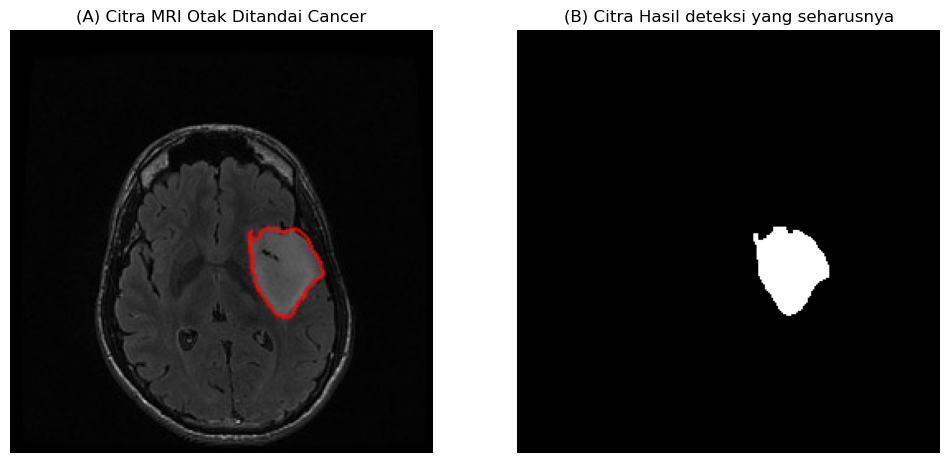

Dimensi Citra MRI: (256, 256, 3)
Dimensi Citra GT : (256, 256)


In [1]:
import cv2, numpy as np, matplotlib.pyplot as plt

image_mri = cv2.imread('Assets/img/BrainMRI.jpg')
image_mri_rgb = cv2.cvtColor(image_mri, cv2.COLOR_BGR2RGB)

image_gt = cv2.imread('Assets/img/BrainGT.tif', cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(12, 6))

# Plot Citra A
plt.subplot(1, 2, 1)
plt.imshow(image_mri_rgb)
plt.title("(A) Citra MRI Otak Ditandai Cancer")
plt.axis('off')

# Plot Citra B
plt.subplot(1, 2, 2)
plt.imshow(image_gt, cmap='gray')
plt.title("(B) Citra Hasil deteksi yang seharusnya")
plt.axis('off')

plt.show()

print(f"Dimensi Citra MRI: {image_mri.shape}")
print(f"Dimensi Citra GT : {image_gt.shape}")

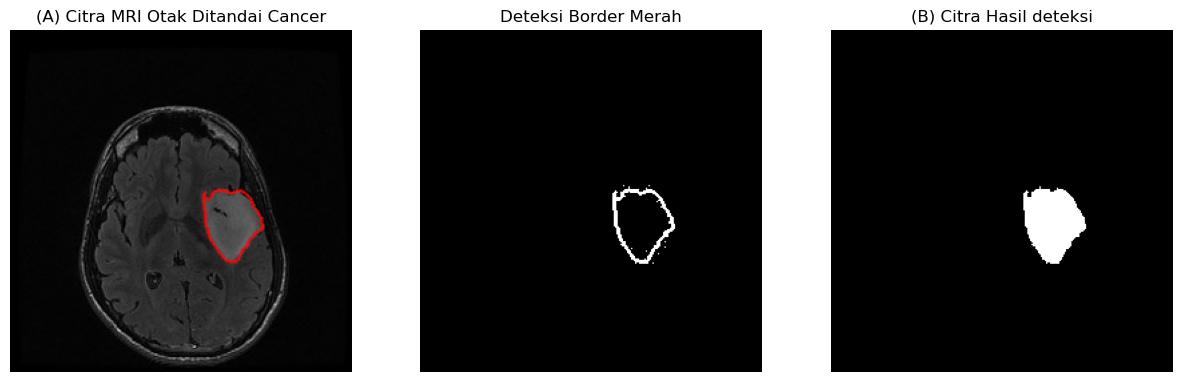

In [2]:
# 1. Load Citra
img_mri = cv2.imread('Assets/img/BrainMRI.jpg')
img_rgb = cv2.cvtColor(img_mri, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_mri, cv2.COLOR_BGR2HSV)

# 2. Deteksi Warna Merah (Red Border)
lower_red1 = np.array([0, 50, 50])
upper_red1 = np.array([10, 255, 255])
lower_red2 = np.array([170, 50, 50])
upper_red2 = np.array([180, 255, 255])
mask1 = cv2.inRange(img_hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(img_hsv, lower_red2, upper_red2)
mask_border = mask1 + mask2

# 3. Mengisi Area di dalam Border (Filling)
contours, _ = cv2.findContours(mask_border, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_cancer_filled = np.zeros_like(mask_border)

if contours:
    c = max(contours, key=cv2.contourArea)
    cv2.drawContours(mask_cancer_filled, [c], -1, 255, thickness=cv2.FILLED)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img_rgb)
plt.title("(A) Citra MRI Otak Ditandai Cancer")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_border, cmap='gray')
plt.title("Deteksi Border Merah")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(mask_cancer_filled, cmap='gray')
plt.title("(B) Citra Hasil deteksi")
plt.axis('off')

plt.show()

## 2. Ukur luasan cancer jika resolusinya adalah $10^3$ PPI
Jawaban image 2 hitung resolusinya

In [3]:
# Parameter Resolusi
PPI = 1000  # 10^3 Pixels Per Inch

In [4]:
pixel_area_conversion = (1 / PPI) ** 2  # Luas satu piksel dalam inci persegi

# 1. Hitung Luas Hasil Segmentasi (Citra A)
cancer_pixel_count = np.count_nonzero(mask_cancer_filled)
cancer_area_inch = cancer_pixel_count * pixel_area_conversion
cancer_area_cm = cancer_area_inch * (2.54 ** 2) # Konversi ke cm^2

# 2. Hitung Luas Ground Truth (Citra B) untuk Referensi
img_gt = cv2.imread('img/BrainGT.tif', cv2.IMREAD_GRAYSCALE)
# Thresholding untuk memastikan biner murni
_, img_gt_bin = cv2.threshold(img_gt, 127, 255, cv2.THRESH_BINARY)

gt_pixel_count = np.count_nonzero(img_gt_bin)
gt_area_inch = gt_pixel_count * pixel_area_conversion
gt_area_cm = gt_area_inch * (2.54 ** 2)

In [5]:
print(f"Resolusi Citra: {PPI} PPI")
print(f"\n1. HASIL SEGMENTASI (Dari BrainMRI.jpg):")
print(f"   - Jumlah Piksel Kanker : {cancer_pixel_count}")
print(f"   - Luas Fisik (inci^2)  : {cancer_area_inch:.4f} in²")
print(f"   - Luas Fisik (cm^2)    : {cancer_area_cm:.4f} cm²")

print(f"\n2. GROUND TRUTH (Dari BrainGT.tif) [Sebagai Referensi]:")
print(f"   - Jumlah Piksel Kanker : {gt_pixel_count}")
print(f"   - Luas Fisik (inci^2)  : {gt_area_inch:.4f} in²")
print(f"   - Luas Fisik (cm^2)    : {gt_area_cm:.4f} cm²")

Resolusi Citra: 1000 PPI

1. HASIL SEGMENTASI (Dari BrainMRI.jpg):
   - Jumlah Piksel Kanker : 1866
   - Luas Fisik (inci^2)  : 0.0019 in²
   - Luas Fisik (cm^2)    : 0.0120 cm²

2. GROUND TRUTH (Dari BrainGT.tif) [Sebagai Referensi]:
   - Jumlah Piksel Kanker : 0
   - Luas Fisik (inci^2)  : 0.0000 in²
   - Luas Fisik (cm^2)    : 0.0000 cm²


## 3. Berapa nilai akurasi hasil segmentasi cancer yang anda dapatkan dengan mengacu pada citra B

In [6]:
img_gt = cv2.imread('Assets/img/BrainGT.tif', cv2.IMREAD_GRAYSCALE)
_, mask_gt = cv2.threshold(img_gt, 127, 255, cv2.THRESH_BINARY)

mask_pred = mask_cancer_filled

if mask_pred.shape != mask_gt.shape:
    print("Peringatan: Ukuran citra tidak sama, melakukan resize pada prediksi...")
    mask_pred = cv2.resize(mask_pred, (mask_gt.shape[1], mask_gt.shape[0]))

In [7]:
y_pred = mask_pred > 0 # True jika piksel adalah kanker hasil deteksi
y_true = mask_gt > 0   # True jika piksel adalah kanker di kunci jawaban

# Hitung Intersection (Irisan) dan Union (Gabungan)
intersection = np.logical_and(y_pred, y_true)
union = np.logical_or(y_pred, y_true)

In [8]:
# A. Pixel Accuracy
# (Benar Positif + Benar Negatif) / Total Piksel
correct_pixels = np.sum(y_pred == y_true)
total_pixels = y_pred.size
pixel_acc = correct_pixels / total_pixels

# B. IoU (Jaccard Index)
# Area Irisan / Area Gabungan
iou = np.sum(intersection) / np.sum(union)

# C. Dice Coefficient (F1 Score)
# 2 * Area Irisan / (Total Area Prediksi + Total Area GT)
dice = 2 * np.sum(intersection) / (np.sum(y_pred) + np.sum(y_true))

In [9]:
print(f"1. Pixel Accuracy : {pixel_acc:.4f} ({pixel_acc*100:.2f}%)")
print(f"2. Jaccard (IoU)  : {iou:.4f} ({iou*100:.2f}%)")
print(f"3. Dice Score     : {dice:.4f} ({dice*100:.2f}%)")

1. Pixel Accuracy : 0.9960 (99.60%)
2. Jaccard (IoU)  : 0.8616 (86.16%)
3. Dice Score     : 0.9257 (92.57%)


## 4. Citra A dan B tersedia pada G-classroom, code di upload pada G-classroom

- [Code](https://github.com/rhindottire/Data-Science/tree/main/project/Citra)
- [BrainMRI.jpg](https://classroom.google.com/u/0/c/Nzk0ODg1ODc3MDU0/a/ODM2NTIwODIyNjcz/details)
- [BrainGT.tif](https://classroom.google.com/u/0/c/Nzk0ODg1ODc3MDU0/a/ODM2NTIwODIyNjcz/details)